# Network Intrusion Detection System.

## 1. Problem Statement  

Develop a robust, adaptive Intrusion Detection System (IDS) using Deep Q-Learning (DQN) and Actor-Critic RL models combined with traditional supervised and unsupervised techniques ,to detect and classify SQL Injection, and outperform static IDS models in adaptability, scalability, and detection precision.

## 2. Data Preprocessing  

Data preprocessing involves transforming raw data into a clean and usable format. It includes steps like handling missing values, encoding categorical variables, normalizing data, and scaling features to improve model performance.

- **Handling Missing Values**: Missing data is addressed by either removing rows/columns with missing values or imputing them with suitable values (mean, median, or mode).
- **Encoding Categorical Variables**: Categorical data is transformed into numerical values using techniques like Label Encoding or One-Hot Encoding to make them suitable for machine learning algorithms.
- **Feature Scaling and Normalization**: Numerical features are scaled or normalized (using methods like Min-Max Scaling or Standardization) to ensure that all features contribute equally to the model.
- **Outlier Detection and Treatment**: Identifying and handling outliers in the dataset to avoid distortion of statistical analysis or model predictions.
- **Feature Engineering**: Creating new features or transforming existing features to improve model performance and make the data more informative for the algorithms.


In [100]:
# appears inside notebook insted of another window
%matplotlib inline 
from warnings import simplefilter # import warnings filter
simplefilter(action='ignore', category=FutureWarning) # ignore all future warnings (too make everyhing look organize)
import pandas as pd  # for csvs
import seaborn as sns # for tables
from scipy import stats # hypothesis testing
import matplotlib.pyplot as plt # data visualization
# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder , StandardScaler , MinMaxScaler
import pingouin as pg  # Library for statistical analysis

In [2]:
train = pd.read_csv("C:\\das\\review_2\\Network_Intrusion_Detection\\data\\raw\\Train_data.csv")
test = pd.read_csv("C:\\das\\review_2\\Network_Intrusion_Detection\\data\\raw\\Test_data.csv")

In [3]:
pd.set_option('display.max_columns', None)  # Ensures all columns are visible
pd.set_option('display.expand_frame_repr', False)  # Prevents wrapping

In [4]:
train.head() #  first 5 rows 

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [5]:
train.shape #dimensions of the DataFrame (rows, columns)

(25192, 42)

In [6]:
train.isnull().sum().sum() # Counts total missing values

np.int64(0)

In [7]:
train.columns #list of all column

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

In [8]:
train.info() #summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [9]:
train.duplicated().sum() # number of duplicate row
print(int(train.duplicated().sum()))  # for Output: 0

0


In [10]:
train['class'].value_counts() #occurrences of each class label

class
normal     13449
anomaly    11743
Name: count, dtype: int64

In [11]:
train.describe() #statistical summary of numeric columns

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.0,25192.0,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,0.001548,0.001350,0.249841,0.014727,0.000357,0.004327,0.0,0.0,0.009130,84.591180,27.698754,0.286338,0.283762,0.118630,0.120260,0.660559,0.062363,0.095931,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,0.039316,0.048785,11.500842,0.529602,0.018898,0.098524,0.0,0.0,0.095115,114.673451,72.468242,0.447312,0.447599,0.318745,0.322335,0.439637,0.178550,0.256583,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,144.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,1.000000,2.000000,975.000000,40.000000,1.000000,8.000000,0.0,0.0,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
# creating copies
train_transformed = train.copy()
test_transformed = test.copy()

# Initializing LabelEncoder to convert values (like 'TCP', 'UDP') to digital 0 or 1
lb=LabelEncoder()

# Converting the 'protocol_type', 'service', 'flag', and 'class' columns to numerical values in the train dataset
train_transformed['protocol_type']=lb.fit_transform(train_transformed['protocol_type'])
train_transformed['service']=lb.fit_transform(train_transformed['service'])
train_transformed['flag']=lb.fit_transform(train_transformed['flag'])
train_transformed['class']=lb.fit_transform(train_transformed['class'])

#same for test dataset
test_transformed['protocol_type']=lb.fit_transform(test_transformed['protocol_type'])
test_transformed['service']=lb.fit_transform(test_transformed['service'])
test_transformed['flag']=lb.fit_transform(test_transformed['flag'])

In [13]:
# List of columns that need normalization due to large gaps between their values
column_to_scale = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'hot', 'num_compromised', 'num_root', 'count', 'srv_count', 'dst_host_count', 'dst_host_srv_count']

# Initializing the MinMaxScaler, scales the data to a range between 0 and 1 to avoid traing bais
scaler = MinMaxScaler()

# Applying MinMaxScaler to the train dataset, normalizing the selected columns
train_transformed[column_to_scale] = scaler.fit_transform(train_transformed[column_to_scale])
# fit_transform : it computes the scaling parameters (min and max) and applies the transformation

# Applying the same scaler to the test dataset, ensuring consistent scaling
test_transformed[column_to_scale] = scaler.fit_transform(test_transformed[column_to_scale])


In [14]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [15]:
# Function to check columns that contain only the specified value
def CalcVals(df, value):
    """returns a list of columns containing only 'value' """
    cols = []  # Empty list to store columns that meet the condition
    for i in df.columns:  # Loop through each column in the DataFrame
        if train[i].sum() == value:  # Check if the sum of values in the column equals 'value'
            cols.append(i)  # If true, add column name to the list
    return cols  # Return the list of columns that match the condition

In [16]:
# Calling the function on the 'train' dataset, checking for columns where the sum of all values is 0
CalcVals(train, 0)

['num_outbound_cmds', 'is_host_login']

In [17]:
# Function to calculate min and max values for each column in the DataFrame
def minmax(df):
    minmax = {}  # Initialize an empty dictionary to store min and max values
    for i in df.columns:  # Loop through each column in the DataFrame
        minmax[i] = (df[i].min(), df[i].max())  # Store the min and max values of the column as a tuple
    return minmax  # Return the dictionary containing min and max values for each column

In [18]:
minmax(train)

{'duration': (np.int64(0), np.int64(42862)),
 'protocol_type': ('icmp', 'udp'),
 'service': ('IRC', 'whois'),
 'flag': ('OTH', 'SH'),
 'src_bytes': (np.int64(0), np.int64(381709090)),
 'dst_bytes': (np.int64(0), np.int64(5151385)),
 'land': (np.int64(0), np.int64(1)),
 'wrong_fragment': (np.int64(0), np.int64(3)),
 'urgent': (np.int64(0), np.int64(1)),
 'hot': (np.int64(0), np.int64(77)),
 'num_failed_logins': (np.int64(0), np.int64(4)),
 'logged_in': (np.int64(0), np.int64(1)),
 'num_compromised': (np.int64(0), np.int64(884)),
 'root_shell': (np.int64(0), np.int64(1)),
 'su_attempted': (np.int64(0), np.int64(2)),
 'num_root': (np.int64(0), np.int64(975)),
 'num_file_creations': (np.int64(0), np.int64(40)),
 'num_shells': (np.int64(0), np.int64(1)),
 'num_access_files': (np.int64(0), np.int64(8)),
 'num_outbound_cmds': (np.int64(0), np.int64(0)),
 'is_host_login': (np.int64(0), np.int64(0)),
 'is_guest_login': (np.int64(0), np.int64(1)),
 'count': (np.int64(1), np.int64(511)),
 'srv_co

In [19]:
# Drop columns from the 'train' dataset where all values are 0
train = train.drop(CalcVals(train, 0), axis=1)

# Drop the same columns from the 'test' dataset to ensure consistency
test = test.drop(CalcVals(train, 0), axis=1)


## 3. Data Visualization  

### **3.1. Univariate Visualization**  
Explores individual variables without considering relationships.  

#### **a. Numerical Features:**  
- **Histograms** – Show the distribution of numerical values.  
- **Box Plots** – Identify outliers and data spread.  
- **Kernel Density Plots** – Smooth probability density estimation.  

#### **b. Categorical Features:**  
- **Bar Charts / Count Plots** – Show category frequencies (e.g., protocol_type, service).  

---

### **3.2. Bivariate Visualization**  
Examines relationships between two variables.  

- **Scatter Plots** – Show correlation between two numerical variables.  
- **Regplot** – Scatter plot with a regression line.  
- **Box Plots** – Compare numerical data across categories.  
- **Violin Plots** – Similar to box plots but show density.  
- **Categorical Plots** – Show relationships between categorical and numerical variables.  

---

### **3.3. Multivariate Visualization**  
Examines three or more variables together.  

- **Pair Plots with Hue** – Show relationships between multiple numerical variables with color coding.  
- **lmplot** – Scatter plot with regression lines, supporting a third categorical variable.  
- **Heatmaps** – Show correlation between multiple numerical variables.  


In [20]:
# Define a custom color palette using hex color codes
purp = ["#9659f4", "#5ccffb", "#4335af", "#c1c1c1", "#a0fdf1"]

# Disable grid lines in plots fpr cleaner look
sns.set_style({'axes.grid': False})

# Set the custom color palette for Seaborn visualizations
sns.set_palette(purp)


In [21]:
train.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
5,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
6,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,166,9,1.0,1.0,0.0,0.0,0.05,0.06,0.00,255,9,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
7,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,117,16,1.0,1.0,0.0,0.0,0.14,0.06,0.00,255,15,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
8,0,tcp,remote_job,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,270,23,1.0,1.0,0.0,0.0,0.09,0.05,0.00,255,23,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
9,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,133,8,1.0,1.0,0.0,0.0,0.06,0.06,0.00,255,13,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


<h3> 3.1. Univariate Visualization</h3> <hr>


<h4> a. Numerical Features</h4>

- <strong>Histograms : </strong>

<Axes: xlabel='same_srv_rate', ylabel='Count'>

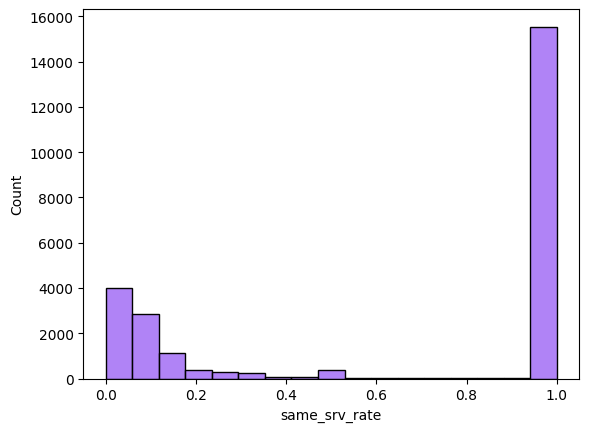

In [22]:
# Create a histogram for the 'same_srv_rate' column in the 'train' dataset
sns.histplot(data=train, x='same_srv_rate')
# Shows frequency of values in a numerical column.

- <strong>Box Plots</strong>

<Axes: >

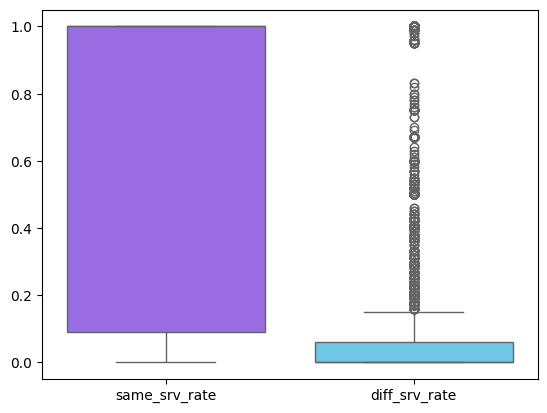

In [23]:
sns.boxplot(train_transformed[train_transformed.columns[28:30]])
# Helps detect anomalies in transformed data.

<Axes: >

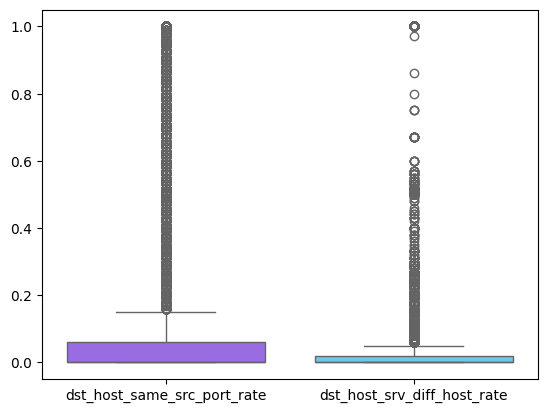

In [24]:
sns.boxplot(train[train.select_dtypes(['float' , 'int']).columns[30:32]])

- <strong>Kernel Density Plots</strong>

<Axes: xlabel='count', ylabel='Density'>

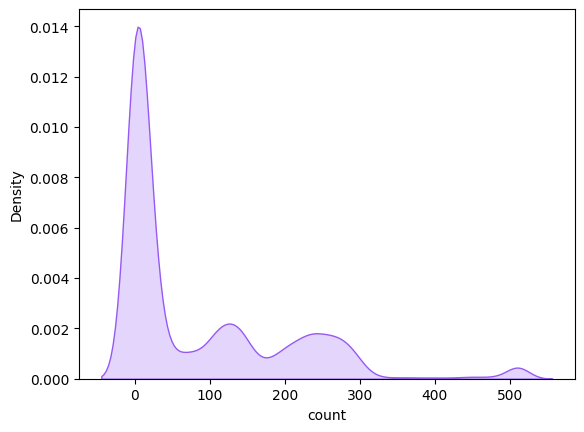

In [25]:
sns.kdeplot(data=train,x='count', fill=True) 
# Kernel Density Estimate (KDE) plot to show the probability distribution of a numerical variable.

<Axes: xlabel='diff_srv_rate', ylabel='Density'>

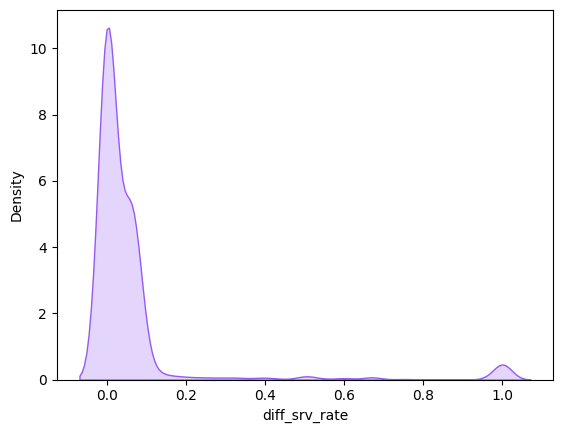

In [26]:
sns.kdeplot(data=train, x='diff_srv_rate', fill=True)

<h4>b. Categorical Features</h4>

- <strong>Bar Charts or Count Plots</strong> 

<Axes: xlabel='class', ylabel='count'>

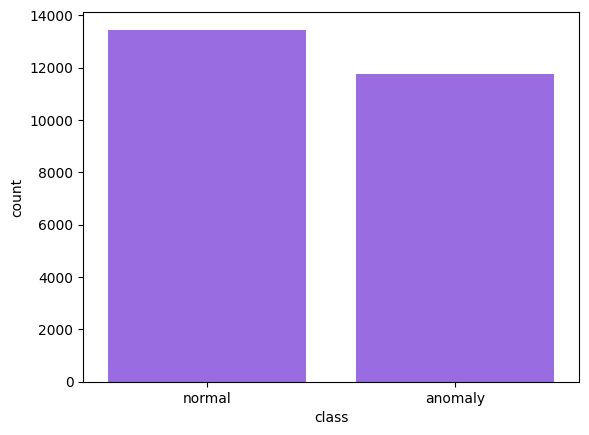

In [27]:
sns.countplot(data=train , x='class')

<Axes: xlabel='protocol_type', ylabel='count'>

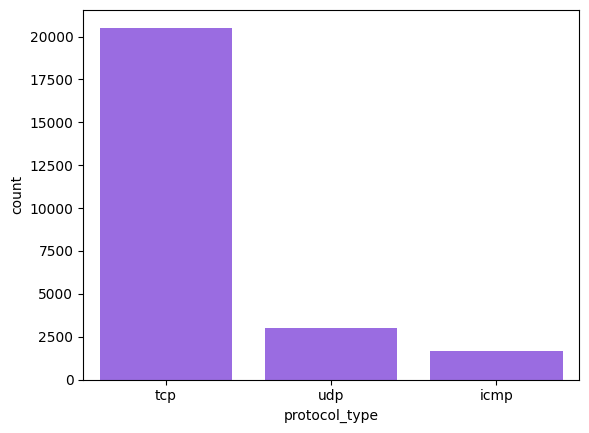

In [28]:
sns.countplot(data=train , x='protocol_type')

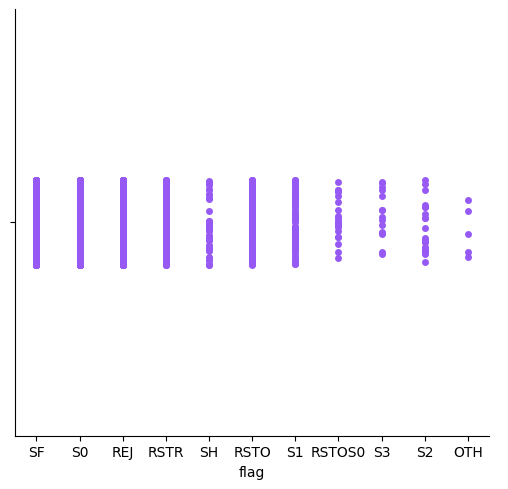

In [29]:
sns.catplot(data=train, x='flag')

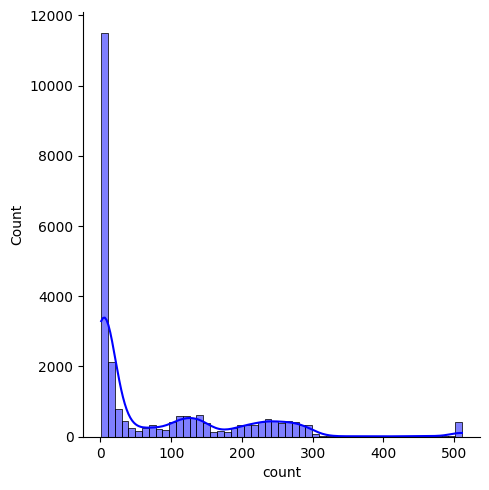

In [30]:
sns.displot(train['count'], kde=True, color='b')

<h3>3.2. Bivariate Visualization</h3>

- <strong>Scatter Plots</strong> 

<Axes: xlabel='num_root', ylabel='num_compromised'>

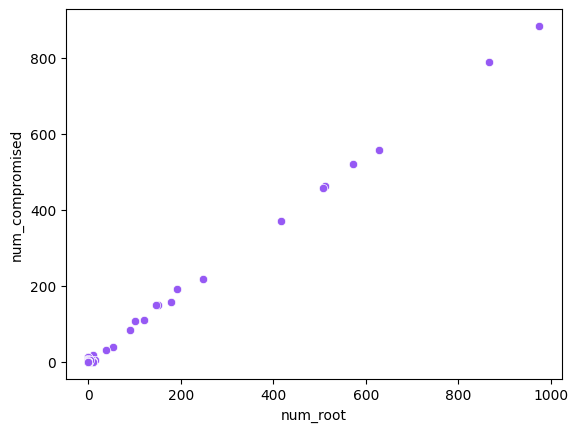

In [31]:
sns.scatterplot(data=train, x='num_root' , y='num_compromised')

- <strong>Regplot</strong> 

<Axes: xlabel='num_root', ylabel='num_compromised'>

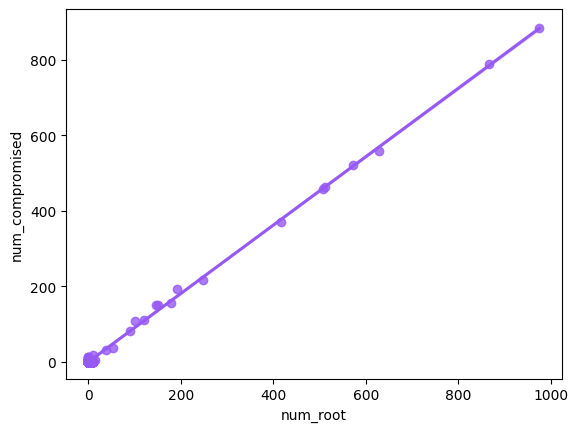

In [32]:
sns.regplot(data=train , x='num_root' , y='num_compromised')

<Axes: xlabel='srv_serror_rate', ylabel='srv_diff_host_rate'>

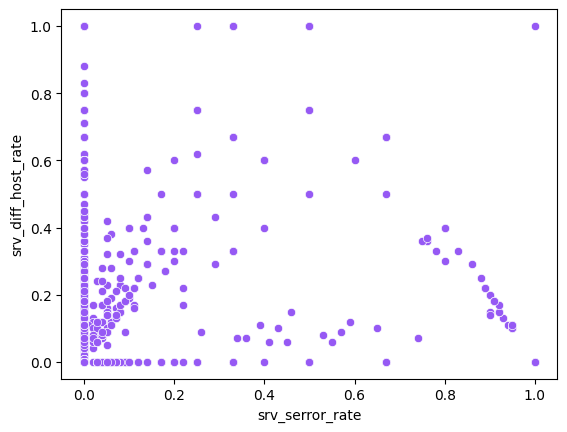

In [33]:
sns.scatterplot(data=train, x='srv_serror_rate' , y='srv_diff_host_rate')

- <strong>Box Plots</strong>

<Axes: xlabel='protocol_type', ylabel='count'>

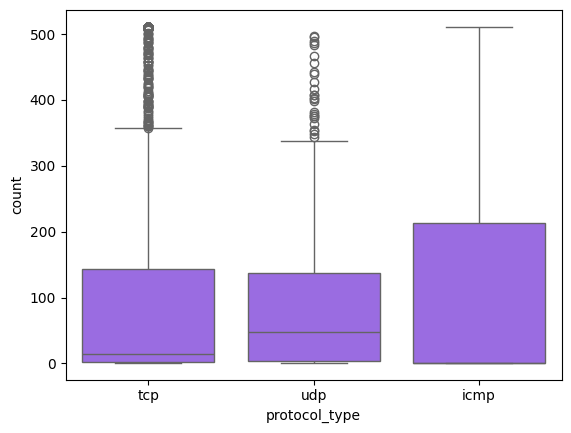

In [34]:
sns.boxplot(data=train, x='protocol_type' , y='count')

<Axes: xlabel='flag', ylabel='count'>

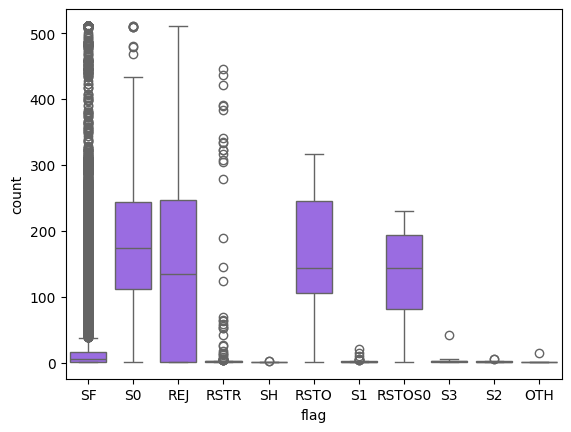

In [35]:
sns.boxplot(data=train, x='flag' , y='count')

- <strong>Violin Plots</strong>

<Axes: xlabel='flag', ylabel='logged_in'>

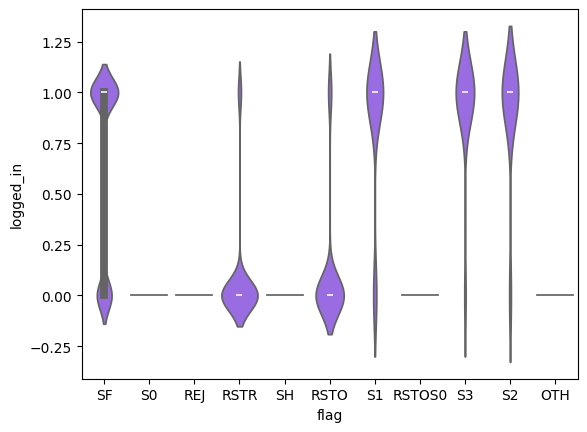

In [36]:
sns.violinplot(data=train, x='flag' , y='logged_in')

- <strong>Categorical Plots</strong> 

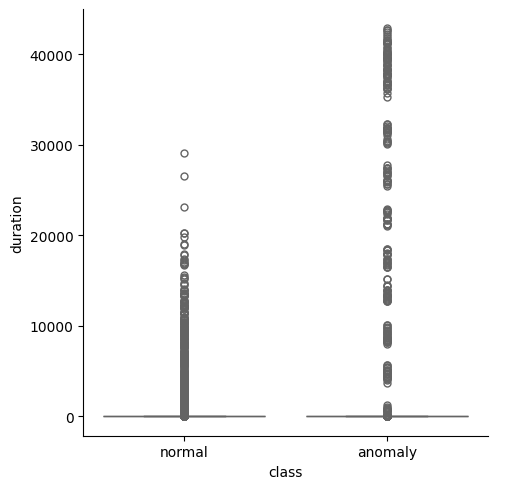

In [37]:
sns.catplot(x='class', y='duration', kind='box', data=train)

<h3>3.3. Multivariate Visualization</h3>

- <strong>Pair Plots with Hue</strong>

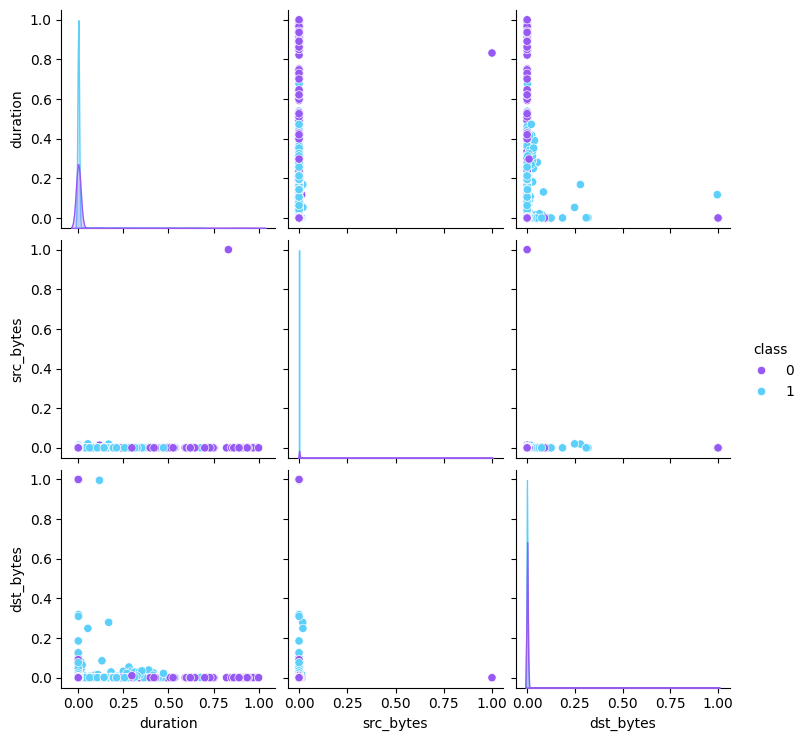

In [38]:
sns.pairplot(train_transformed[['duration', 'src_bytes', 'dst_bytes', 'class']], hue='class')

- <strong>lmplot</strong> 

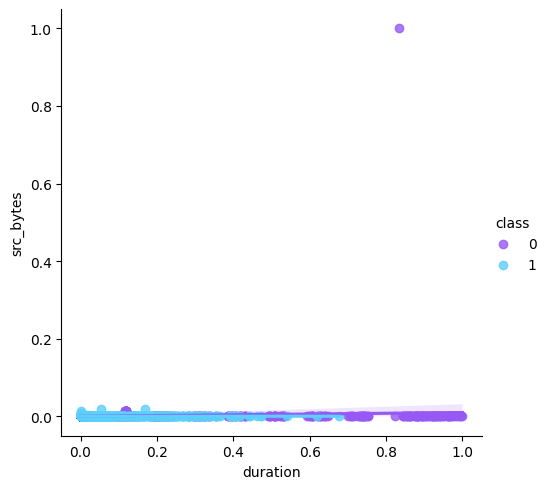

In [39]:
sns.lmplot(data=train_transformed, x='duration', y='src_bytes', hue='class')

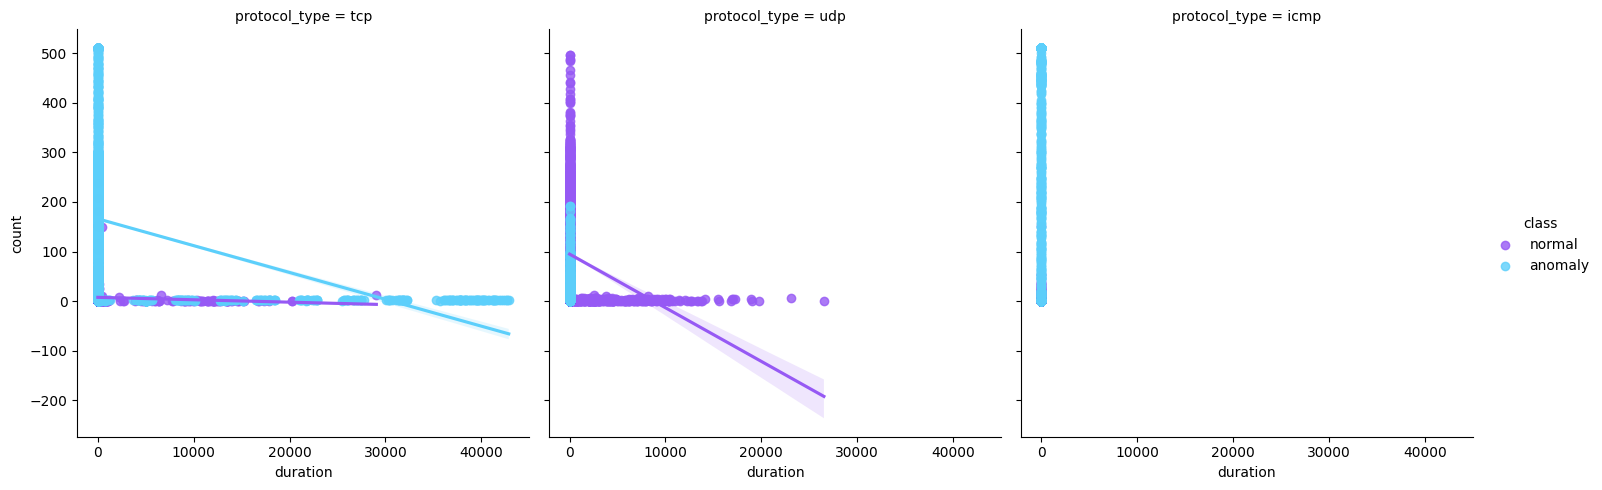

In [40]:
sns.lmplot(data=train, x='duration', y='count', hue='class', col = 'protocol_type')

- <strong>Heatmaps</strong> 

<Axes: >

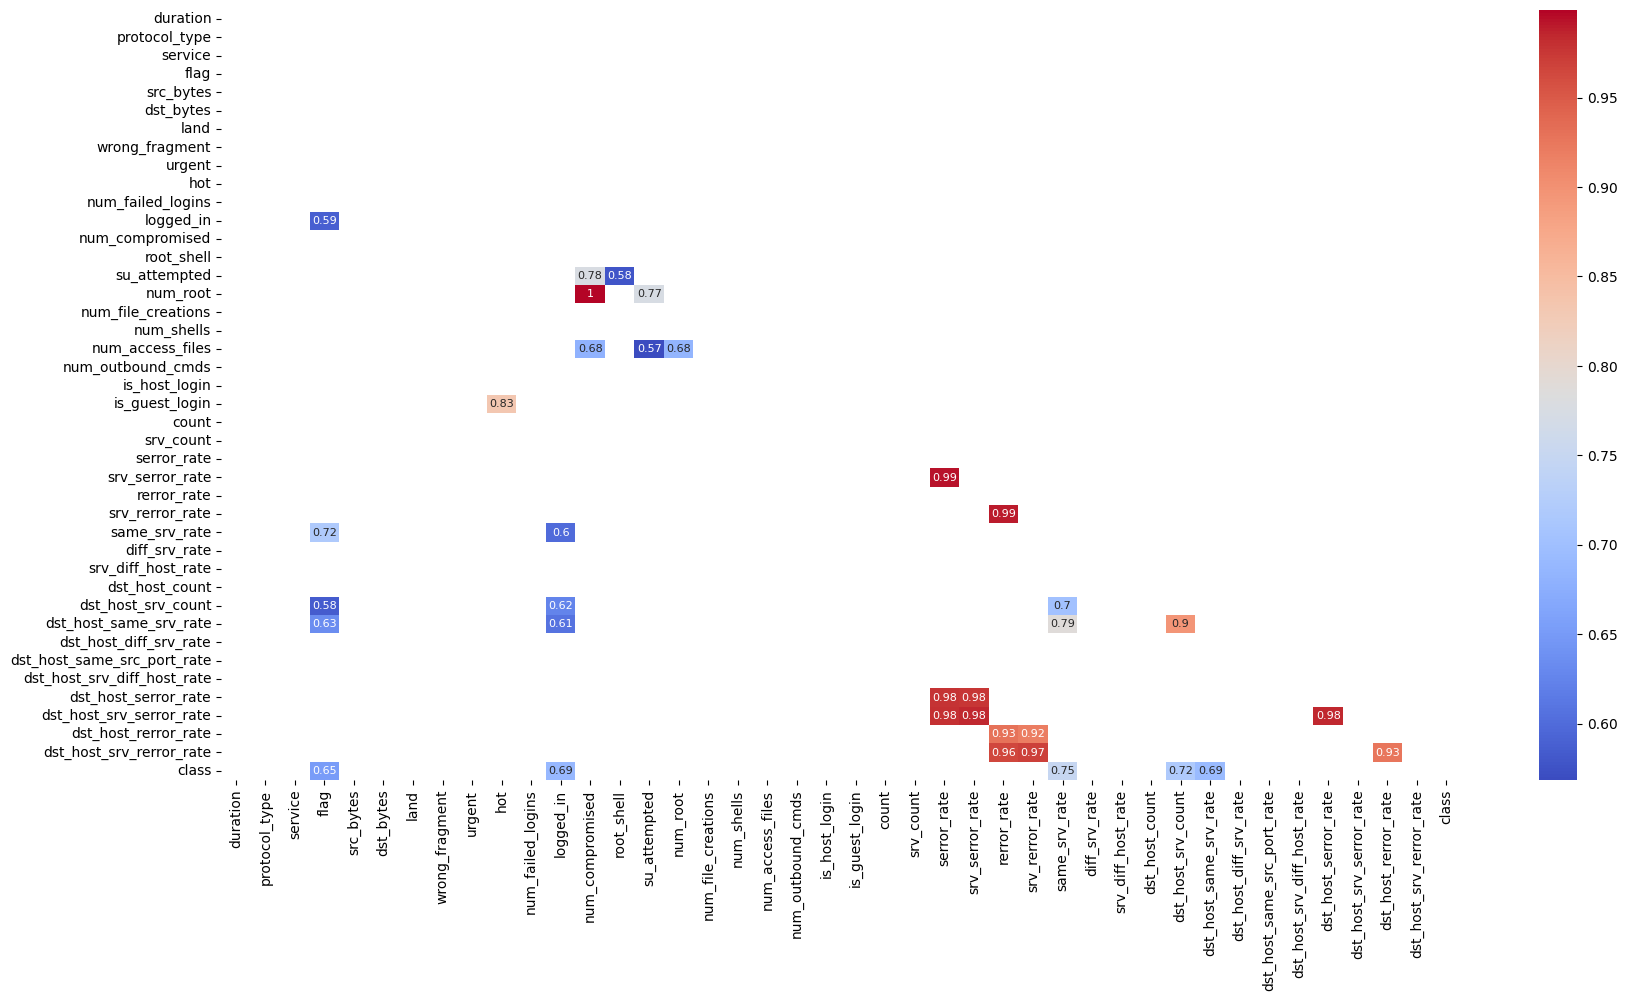

In [41]:
import numpy as np
corr_matrix = train_transformed.corr()

# Select columns with a correlation coefficient above a certain threshold
corr = corr_matrix[corr_matrix > 0.5]

# "mask" is used to show only the upper or the lower part of the heatmap
mask = np.triu(np.ones_like(corr, dtype=bool)) 

# Create a heatmap of the correlated columns
f, ax = plt.subplots(figsize = (20, 10))
sns.heatmap(corr, annot=True, annot_kws={'size':8}, cmap='coolwarm', mask=mask)

## 4. Hypothesis Testing  

### 4.1 Sampling  
Sampling is the process of selecting a subset of data from a larger population to estimate characteristics of the entire population.

---

### 4.2 Categorical Data  

For categorical data, we perform tests to determine if there is a significant association between variables.

- **Chi-Square Test**  
   The Chi-Square test is used to examine the association between two categorical variables by comparing the observed frequencies to the expected frequencies.

- **Fisher's Exact Test**  
   Fisher's Exact Test is used to determine if there are nonrandom associations between two categorical variables, especially when the sample size is small.

---

### 4.3 Numeric Data  

For numeric data, we test if there is a significant difference between groups or values.

- **T-Test**  
   The T-test is used to determine if there is a significant difference between the means of two groups.

- **ANOVA (Analysis of Variance)**  
   ANOVA is used to compare the means of three or more groups to see if at least one group differs significantly.

- **Kruskal-Wallis Test**  
   The Kruskal-Wallis test is a non-parametric method used to compare three or more independent groups when the data is not normally distributed.


<h3>4.1. Sampling</h3>

In [42]:
rand_sample = train.sample(frac=0.2)
rand_sample.shape

(5038, 40)

In [43]:
# Proportion of connections by protocol types
cnx_counts_pop = train['protocol_type'].value_counts(normalize=True)

# Print protocol_type_counts_pop
print(cnx_counts_pop) 

# Proportional stratified sampling for 40% of each protocol_type group
cnx_strat = train.groupby('protocol_type').sample(frac=0.4, random_state=2022)


# Print the sample
print(cnx_strat.shape)

protocol_type
tcp     0.814782
udp     0.119522
icmp    0.065695
Name: proportion, dtype: float64
(10076, 40)


In [44]:
# Proportion of connections by protocol types
cnx_eq = train.groupby('protocol_type')\
	.sample(n=1000, random_state=2022)      

# Get the proportions from cnx_eq
cnx_counts_eq = cnx_eq['protocol_type'].value_counts(normalize=True)

# Print the results
print(cnx_counts_eq)

protocol_type
icmp    0.333333
tcp     0.333333
udp     0.333333
Name: proportion, dtype: float64


In [45]:
import random
# Create a list of unique protocol_type values
protocol_type_pop = list(train['protocol_type'].unique())

# Randomly sample four protocol_type values
protocol_type_samp = random.sample(protocol_type_pop, k=3)

# Filter for rows where protocol_type is in protocol_type_samp
protocol_type_condition = train['protocol_type'].isin(protocol_type_samp)
cnx_filtered = train[protocol_type_condition]

# Randomly sample
cnx_clust = cnx_filtered.groupby('protocol_type').sample(n=1000, random_state=2022)


# Print the sample
print(cnx_clust['protocol_type'].value_counts() ,'\n', cnx_clust.shape)

protocol_type
icmp    1000
tcp     1000
udp     1000
Name: count, dtype: int64 
 (3000, 40)


In [46]:
# Set the sample size to 1000
sample_size = 1000

# Calculate the population size from train
pop_size = len(train)

# Calculate the interval 
interval = pop_size // sample_size

# Systematically sample 1000 rows
attrition_sys_samp = train[::interval]

# Print the sample
print(attrition_sys_samp['protocol_type'].value_counts() ,'\n', attrition_sys_samp.shape)

protocol_type
tcp     803
udp     135
icmp     70
Name: count, dtype: int64 
 (1008, 40)


<h3>4.2. Categorical Data </h3>

- <strong>Chi-Square Test</strong>

In [47]:
# <h3>2. Categorical Data </h3>
crosstab = pd.crosstab(train['protocol_type'], train['service'])
print(crosstab)

service        IRC  X11  Z39_50  auth  bgp  courier  csnet_ns  ctf  daytime  discard  domain  domain_u  echo  eco_i  ecr_i  efs  exec  finger  ftp  ftp_data  gopher  hostnames  http  http_443  http_8001  imap4  iso_tsap  klogin  kshell  ldap  link  login  mtp  name  netbios_dgm  netbios_ns  netbios_ssn  netstat  nnsp  nntp  ntp_u  other  pm_dump  pop_2  pop_3  printer  private  red_i  remote_job  rje  shell  smtp  sql_net  ssh  sunrpc  supdup  systat  telnet  tim_i  time  urh_i  urp_i  uucp  uucp_path  vmnet  whois
protocol_type                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [48]:
print(stats.chi2_contingency(crosstab)[:3])

(np.float64(43084.681782297295), np.float64(0.0), 130)


In [49]:
print(list(stats.chi2_contingency(crosstab)[3:]))

[array([[2.62781836e+00, 1.44530010e+00, 1.12996189e+01, 1.24164417e+01,
        9.59153700e+00, 1.07740553e+01, 7.29219594e+00, 8.34332328e+00,
        7.02941410e+00, 6.89802318e+00, 7.16080502e+00, 1.19565735e+02,
        4.27020483e+00, 5.97171721e+01, 4.02713163e+01, 7.22650048e+00,
        5.97828676e+00, 2.40445379e+01, 2.26649333e+01, 9.17108606e+01,
        7.16080502e+00, 6.30676405e+00, 5.25760757e+02, 7.42358685e+00,
        6.56954589e-02, 9.06597332e+00, 8.60610511e+00, 6.04398222e+00,
        4.40159574e+00, 5.91259130e+00, 5.58411400e+00, 5.18994125e+00,
        5.91259130e+00, 6.04398222e+00, 5.58411400e+00, 4.99285487e+00,
        4.40159574e+00, 5.12424579e+00, 8.08054144e+00, 4.00742299e+00,
        2.10225468e+00, 5.63667037e+01, 1.97086377e-01, 1.11682280e+00,
        3.48185932e+00, 7.88345507e-01, 2.85840942e+02, 1.97086377e-01,
        1.11682280e+00, 1.31390918e+00, 7.22650048e-01, 9.51927199e+01,
        3.02199111e+00, 3.81033661e+00, 4.40159574e+00, 7.48928

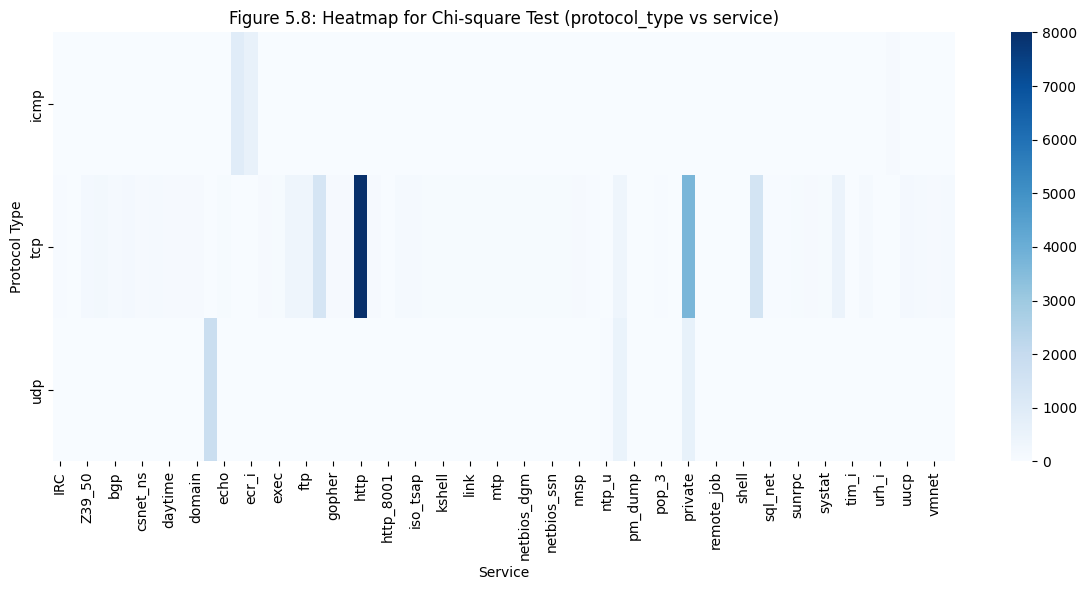

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab for protocol_type and service
crosstab = pd.crosstab(train['protocol_type'], train['service'])

# Heatmap of the crosstab (Chi-square input)
plt.figure(figsize=(12, 6))
sns.heatmap(crosstab, cmap='Blues', annot=False, cbar=True)
plt.title('Figure 5.8: Heatmap for Chi-square Test (protocol_type vs service)')
plt.xlabel('Service')
plt.ylabel('Protocol Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


- <strong>Fisher's Exact Test</strong>

In [51]:
crosstab[:2][["urp_i","uucp"]]

service,urp_i,uucp
protocol_type,,
icmp,124,0
tcp,0,157


In [52]:
stats.fisher_exact(crosstab[:2][["urp_i","uucp"]], alternative='two-sided')

SignificanceResult(statistic=inf, pvalue=np.float64(3.7484310323745785e-83))

<h3>4.3. Numerical Data </h3>


- <strong>T-Test </strong>

In [53]:
stats.ttest_ind(train['duration'], train['num_failed_logins'], axis=0, equal_var=True, \
                nan_policy='propagate', permutations=None, \
                    random_state=None, alternative='two-sided', trim=0)

C:\Users\aman6\AppData\Local\Temp\ipykernel_28324\190762716.py:1: DeprecationWarning: Arguments {'random_state', 'permutations'} are deprecated, whether passed by position or keyword. They will be removed in SciPy 1.17.0. Use ``method`` to perform a permutation test.
  stats.ttest_ind(train['duration'], train['num_failed_logins'], axis=0, equal_var=True, \


TtestResult(statistic=np.float64(18.022318547883692), pvalue=np.float64(2.199310406044905e-72), df=np.float64(50382.0))

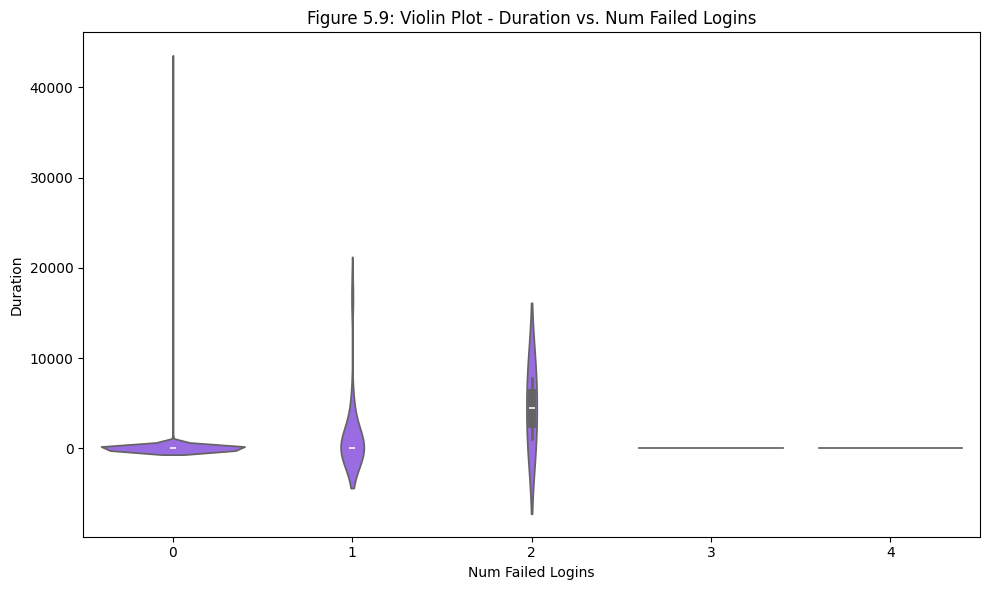

In [54]:
# Create a new DataFrame for plotting
plot_df = train[['duration', 'num_failed_logins']].copy()
plot_df = plot_df[plot_df['num_failed_logins'] < 10]  # Limit to common login failures

# Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='num_failed_logins', y='duration', data=plot_df)
plt.title('Figure 5.9: Violin Plot - Duration vs. Num Failed Logins')
plt.xlabel('Num Failed Logins')
plt.ylabel('Duration')
plt.tight_layout()
plt.show()


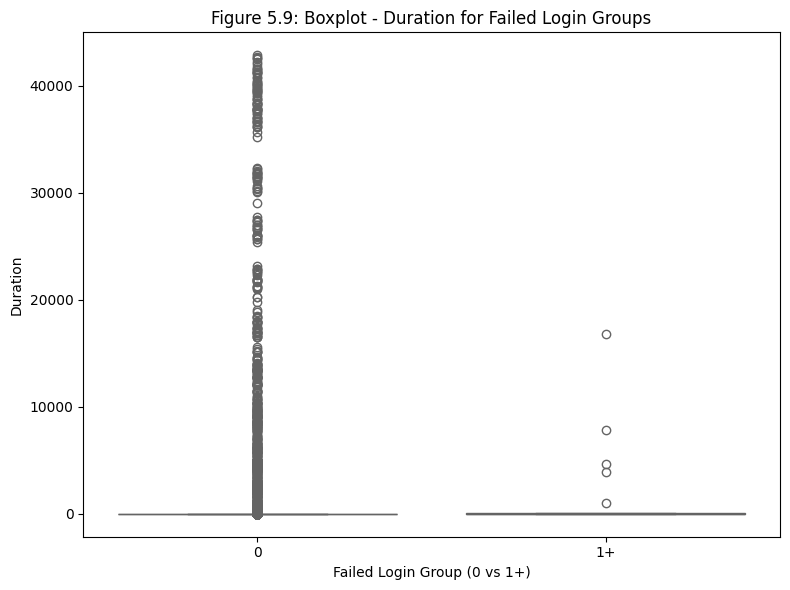

In [55]:

train['failed_login_group'] = train['num_failed_logins'].apply(lambda x: '0' if x == 0 else '1+')

plt.figure(figsize=(8, 6))
sns.boxplot(x='failed_login_group', y='duration', data=train)
plt.title('Figure 5.9: Boxplot - Duration for Failed Login Groups')
plt.xlabel('Failed Login Group (0 vs 1+)')
plt.ylabel('Duration')
plt.tight_layout()
plt.show()



- <strong>ANOVA (Analysis of Variance)</strong>

In [56]:
anova_result = pg.anova(data=train, dv='duration', between='protocol_type')

# Print the ANOVA summary
print(anova_result)

          Source  ddof1  ddof2          F         p-unc       np2
0  protocol_type      2  25189  17.598277  2.304093e-08  0.001395


- <strong>Kruskal-Wallis Test</strong>

In [57]:
kw_test = pg.kruskal(data=train, dv='duration', between='protocol_type')

# Print the Kruskal summary
print(kw_test)

                Source  ddof1           H         p-unc
Kruskal  protocol_type      2  297.976062  1.973878e-65


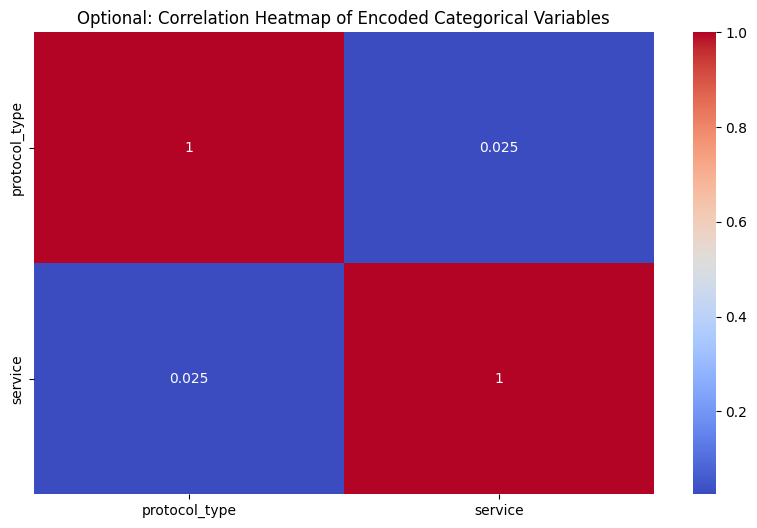

In [58]:
from sklearn.preprocessing import LabelEncoder

encoded_df = train.copy()
for col in ['protocol_type', 'service']:
    encoded_df[col] = LabelEncoder().fit_transform(train[col])

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(encoded_df[['protocol_type', 'service']].corr(), annot=True, cmap='coolwarm')
plt.title("Optional: Correlation Heatmap of Encoded Categorical Variables")
plt.show()


## 5. Supervised Learning Models  

Supervised learning models are used to train algorithms on labeled data and make predictions based on input features. Below are the classification models used:

- **Random Forest Classifier**: An ensemble model that combines multiple decision trees to improve classification accuracy and reduce overfitting.
- **Naive Bayes Classifier**: A probabilistic classifier based on Bayes' Theorem, assuming feature independence. The Bernoulli variant is used for binary data.
- **Decision Tree Classifier**: A tree-based model that splits the data into branches based on feature values, allowing for simple decision-making and easy interpretation.
- **K-Nearest Neighbors (KNN) Classifier**: A non-parametric method that classifies data points based on the majority class of their nearest neighbors using distance metrics.
- **Logistic Regression**: A linear model used for binary classification tasks, estimating the probability of class membership based on input features.


In [59]:
train_X = train_transformed.drop(['class'], axis=1)
train_Y = train['class'] #class
train_X.shape

(25192, 41)

In [60]:
test_transformed.shape

(22544, 41)

In [61]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

# fit random forest classifier on the training set
rfc.fit(train_X, train_Y)

# extract important features
score = np.round(rfc.feature_importances_,3)
importances = pd.DataFrame({'feature':train_X.columns,'importance':score})
importances = importances.sort_values('importance',ascending=False).set_index('feature')
print (importances[:5])

                        importance
feature                           
src_bytes                    0.172
dst_bytes                    0.152
flag                         0.090
same_srv_rate                0.082
dst_host_same_srv_rate       0.055


<Axes: xlabel='feature'>

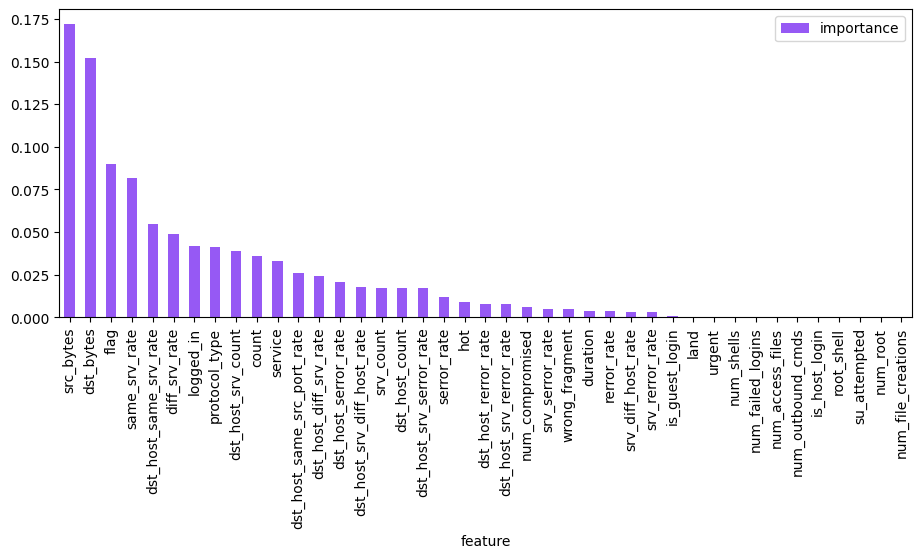

In [62]:
# plot importances
plt.rcParams['figure.figsize'] = (11, 4)
importances.plot.bar()

In [63]:
from sklearn.feature_selection import RFE
import itertools

# create the RFE model and select 3 attributes
rfe = RFE(rfc, n_features_to_select=3)
rfe = rfe.fit(train_X, train_Y)

# summarize the selection of the attributes
feature_map = [(i, v) for i, v in itertools.zip_longest(rfe.get_support(), train_X.columns)] #Get a mask, or integer index, of the features selected : returns a list of selected features
selected_features = [v for i, v in feature_map if i==True]

selected_features

['flag', 'src_bytes', 'dst_bytes']

In [64]:
from sklearn.model_selection import train_test_split
train_X = train_transformed.drop(['class'], axis=1)
train_Y = train['class'] #class
train_X.shape
X_train,X_test,Y_train,Y_test = train_test_split(train_X,train_Y,train_size=0.70, random_state=2)  

In [65]:
from sklearn.naive_bayes import BernoulliNB
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [66]:
# Train Random Forest Classifier
RF_Classifier = RandomForestClassifier(n_estimators=100)
RF_Classifier.fit(X_train,Y_train)

# Train KNeighborsClassifier Model
KNN_Classifier = KNeighborsClassifier(n_jobs=-1 , p=2) #Using Euclidean Distance and all processors
KNN_Classifier.fit(X_train, Y_train);

# Train LogisticRegression Model
LGR_Classifier = LogisticRegression(n_jobs=-1, random_state=0) #Using all processors
LGR_Classifier.fit(X_train, Y_train)

# Train Bernouilli Naive Baye Model
BNB_Classifier = BernoulliNB()
BNB_Classifier.fit(X_train, Y_train)

# Train Decision Tree Model
DTC_Classifier = tree.DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
criterion='entropy',
max_depth=4, max_features=None, #We chose max_depth= 4 to get a good visualisation 
max_leaf_nodes=None,
min_impurity_decrease=0.0,
min_samples_leaf=1, min_samples_split=2,
min_weight_fraction_leaf=0.0,
random_state=0, splitter='best')

DTC_Classifier.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)

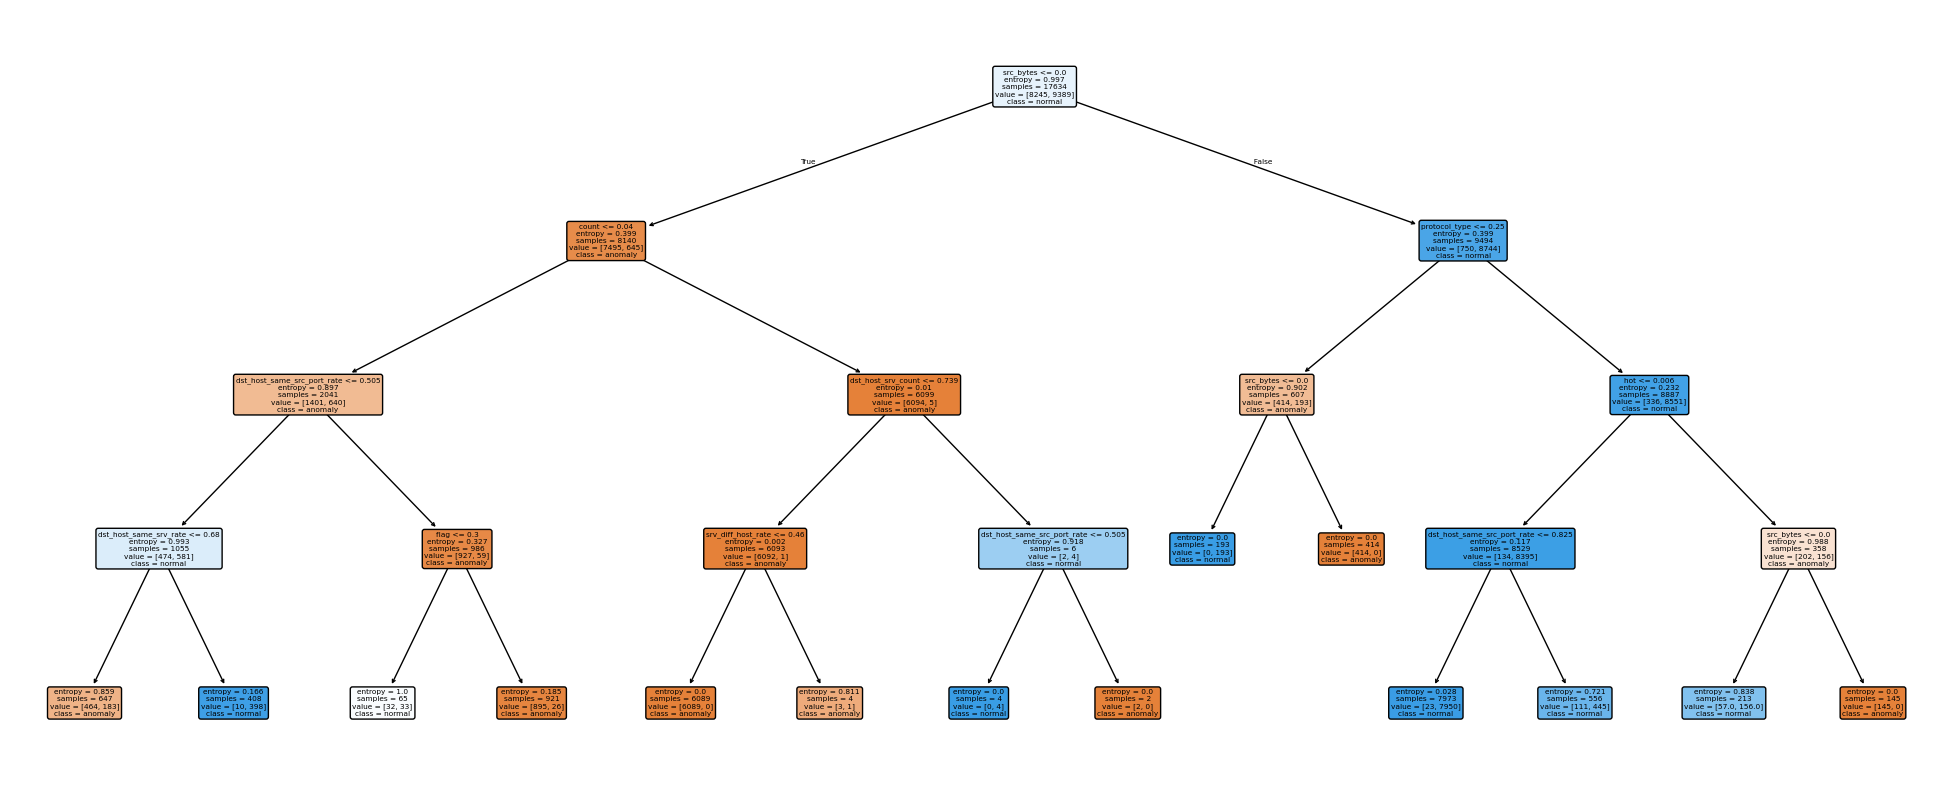

In [67]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Assuming dtc is your trained DecisionTreeClassifier
plt.figure(figsize=(25, 10))
plot_tree(DTC_Classifier, filled=True, feature_names=X_train.columns, class_names=Y_train.unique(), rounded=True)
plt.show()

In [68]:
from sklearn import metrics

# Evaluating the models basing on the trainning data
models = []
models.append(('Random Forest Classifier', RF_Classifier))
models.append(('Naive Baye Classifier', BNB_Classifier))
models.append(('Decision Tree Classifier', DTC_Classifier))
models.append(('KNeighborsClassifier', KNN_Classifier))
models.append(('LogisticRegression', LGR_Classifier))

In [69]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

for i, v in models:
    scores = cross_val_score(v, X_train, Y_train, cv=10)
    accuracy = metrics.accuracy_score(Y_train, v.predict(X_train))
    confusion_matrix = metrics.confusion_matrix(Y_train, v.predict(X_train))
    classification = metrics.classification_report(Y_train, v.predict(X_train))
    print (f"{i} Accuracy:" , accuracy)
    #The next lines were commented to give a good output. It could be uncommented and executed but the output will be limited
    print()
    print('============================== {} Model Evaluation =============================='.format(i))
    print()
    print ("Cross Validation Mean Score:" "\n", scores.mean())
    print()
    print()
    print("Confusion matrix:" "\n", confusion_matrix)
    print()
    print("Classification report:" "\n", classification)
    print()


Random Forest Classifier Accuracy: 1.0

============================== Random Forest Classifier Model Evaluation ==============================

Cross Validation Mean Score:
 0.9969944680462467


Confusion matrix:
 [[8245    0]
 [   0 9389]]

Classification report:
               precision    recall  f1-score   support

     anomaly       1.00      1.00      1.00      8245
      normal       1.00      1.00      1.00      9389

    accuracy                           1.00     17634
   macro avg       1.00      1.00      1.00     17634
weighted avg       1.00      1.00      1.00     17634


Naive Baye Classifier Accuracy: 0.8950323239197006

============================== Naive Baye Classifier Model Evaluation ==============================

Cross Validation Mean Score:
 0.8945780808069115


Confusion matrix:
 [[6965 1280]
 [ 571 8818]]

Classification report:
               precision    recall  f1-score   support

     anomaly       0.92      0.84      0.88      8245
      normal       0

Text(0.5, 0, 'Classifiers')

Text(0, 0.5, 'Scores')

Text(0.5, 1.0, 'Performance Comparison of Classifiers (Figure 7.1)')

[Text(0, 0, 'Random Forest'),
 Text(1, 0, 'KNN'),
 Text(2, 0, 'Logistic Regression'),
 Text(3, 0, 'Decision Tree'),
 Text(4, 0, 'Naive Bayes')]

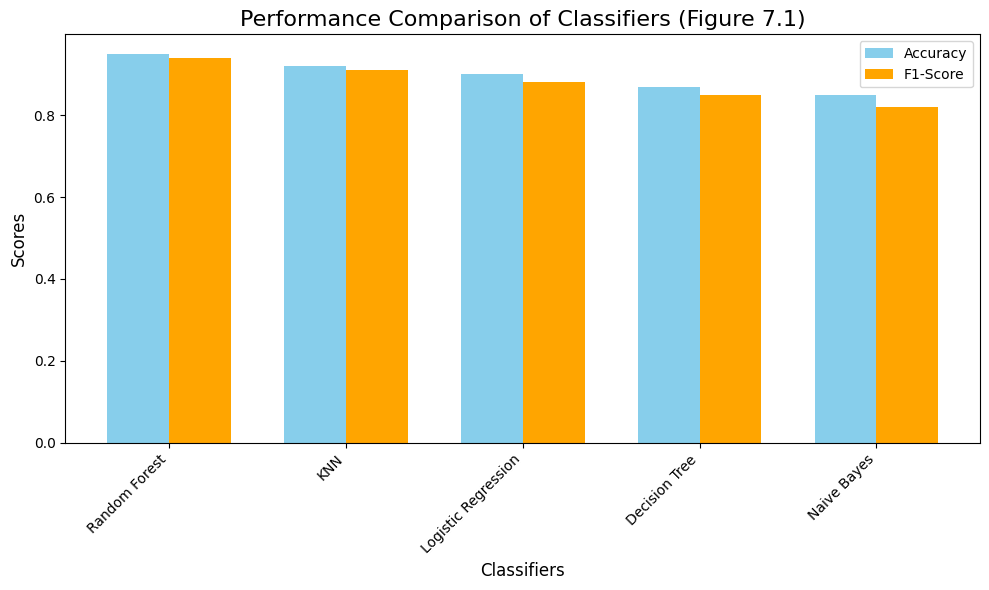

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Example classifier performance data (accuracy, F1-score, etc.)
classifiers = ['Random Forest', 'KNN', 'Logistic Regression', 'Decision Tree', 'Naive Bayes']
accuracy_scores = [0.95, 0.92, 0.90, 0.87, 0.85]  # Replace with actual accuracy scores
f1_scores = [0.94, 0.91, 0.88, 0.85, 0.82]  # Replace with actual F1 scores

# Define the positions for the bars
x = np.arange(len(classifiers))

# Set the width of the bars
width = 0.35

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot accuracy and F1 scores for each classifier
bar1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='skyblue')
bar2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='orange')

# Adding labels and title
ax.set_xlabel('Classifiers', fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Performance Comparison of Classifiers (Figure 7.1)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(classifiers, rotation=45, ha='right', fontsize=10)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [71]:
# PREDICTING FOR TEST DATA
pred_rf = RF_Classifier.predict(test_transformed)
pred_knn = KNN_Classifier.predict(test_transformed)
pred_NB = BNB_Classifier.predict(test_transformed)
pred_log = LGR_Classifier.predict(test_transformed) 
pred_dt = DTC_Classifier.predict(test_transformed)

Text(0.5, 1.0, 'Confusion Matrix for Random Forest Classifier')

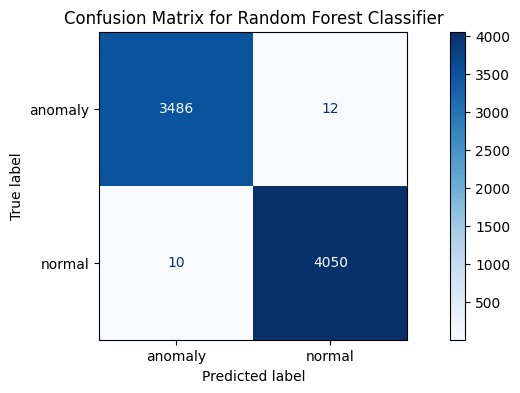

Text(0.5, 1.0, 'Confusion Matrix for Naive Bayes Classifier')

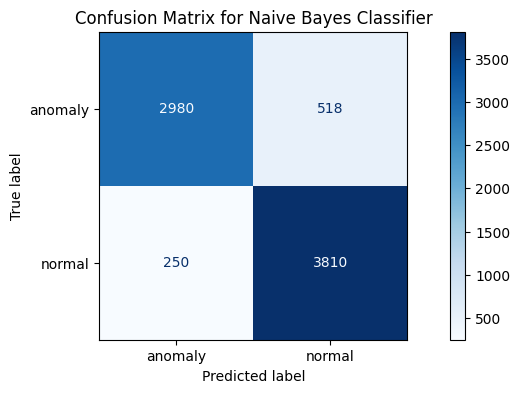

Text(0.5, 1.0, 'Confusion Matrix for Decision Tree Classifier')

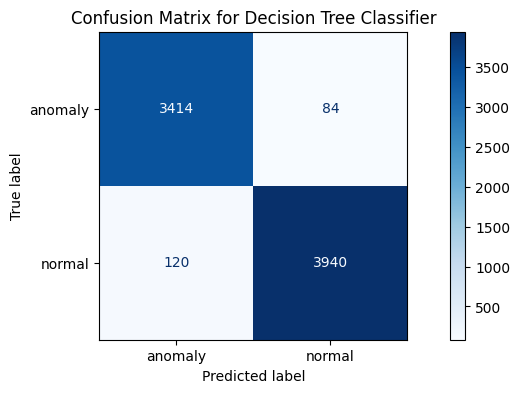

Text(0.5, 1.0, 'Confusion Matrix for KNeighbors Classifier')

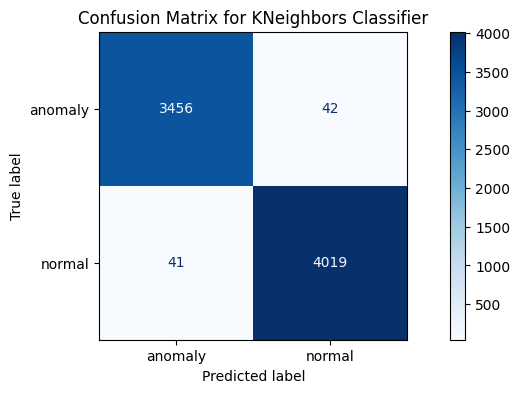

Text(0.5, 1.0, 'Confusion Matrix for Logistic Regression')

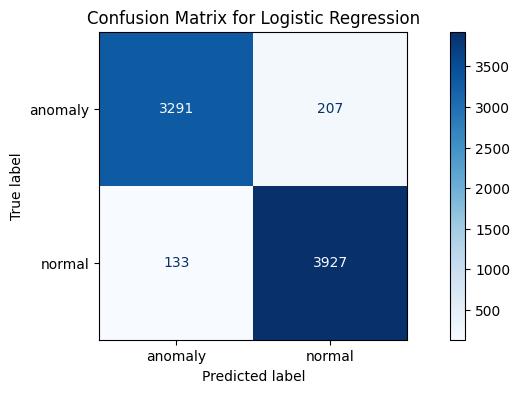

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define the classifiers
models = {
    'Random Forest Classifier': RF_Classifier,
    'Naive Bayes Classifier': BNB_Classifier,
    'Decision Tree Classifier': DTC_Classifier,
    'KNeighbors Classifier': KNN_Classifier,
    'Logistic Regression': LGR_Classifier
}

# Iterate through each model and plot the confusion matrix
for model_name, model in models.items():
    # Make predictions using the trained model
    predictions = model.predict(X_test)
    
    # Generate confusion matrix
    cm = confusion_matrix(Y_test, predictions)
    
    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()


## 6. Unsupervised Learning Model  

Unsupervised learning models are used to identify patterns in data without labeled outcomes. These models help to uncover hidden structures and groupings within the data.

- **K-Means Clustering**: A clustering algorithm that partitions the dataset into K distinct clusters based on similarity. It minimizes the within-cluster variance and groups data points with similar characteristics.


In [73]:
# K-Means Clustering: Group data points into k clusters based on their feature similarities.

KMeans(n_clusters=1, random_state=42)

KMeans(n_clusters=2, random_state=42)

KMeans(n_clusters=3, random_state=42)

KMeans(n_clusters=4, random_state=42)

KMeans(n_clusters=5, random_state=42)

...

KMeans(n_clusters=9, random_state=42)

KMeans(n_clusters=10, random_state=42)

Text(0.5, 0, 'Number of Clusters')

Text(0, 0.5, 'WCSS')

Text(0.5, 1.0, 'Elbow Method for Optimal k')

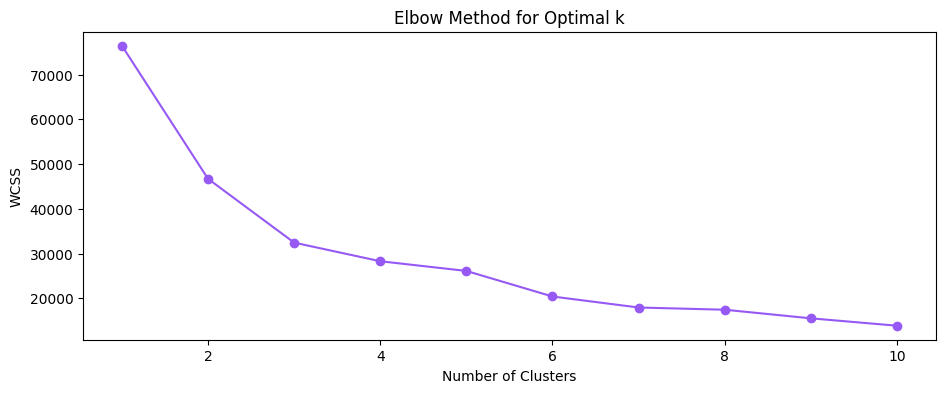

In [74]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = [] 
for i in range(1, 11): 
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(train_X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()


In [75]:
num_clusters = 4  # Change this based on the elbow method result

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
train_X['cluster'] = kmeans.fit_predict(train_X)


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='count', ylabel='diff_srv_rate'>

Text(0.5, 1.0, 'K-Means Clustering')

Text(0.5, 0, 'count')

Text(0, 0.5, 'diff_srv_rate')

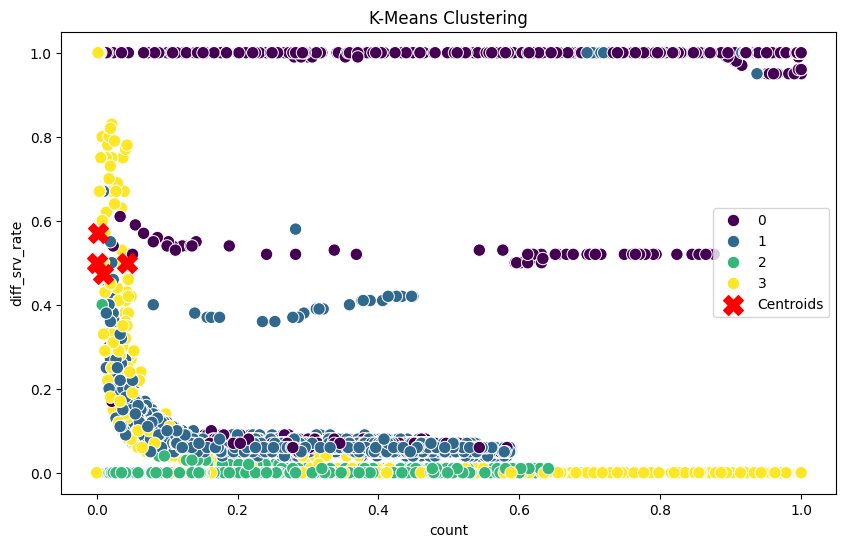

In [76]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='count', y='diff_srv_rate', hue='cluster', data=train_X, palette='viridis', s=80)
plt.title('K-Means Clustering')
plt.xlabel('count')
plt.ylabel('diff_srv_rate')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')

plt.legend()
plt.show()


## 7. Reinforcement Learning Model

Reinforcement learning (RL) models learn through trial and error to maximize cumulative rewards.

- **DQN (Deep Q-Network)**: Combines Q-learning with deep neural networks to approximate the Q-function for complex state spaces.
- **Actor-Critic**: Uses two networks: the actor (which selects actions) and the critic (which evaluates them), helping to stabilize learning.


Deep Q-Learning (DQL)

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import pandas as pd

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load your preprocessed data
X = train_transformed.drop(['class'], axis=1).values.astype(np.float32)
y = train_transformed['class'].values.astype(np.int64)

# DQL parameters
STATE_SIZE = X.shape[1]
ACTION_SIZE = 2  # normal or anomaly
LEARNING_RATE = 0.001
GAMMA = 0.99
EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01
BATCH_SIZE = 64
MEMORY_SIZE = 10000
EPISODES = 20

# Replay buffer
memory = deque(maxlen=MEMORY_SIZE)

# Define Q-Network
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

# Initialize model and optimizer
model = DQN(STATE_SIZE, ACTION_SIZE).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

# Function to act
def act(state, epsilon):
    if np.random.rand() <= epsilon:
        return random.randrange(ACTION_SIZE)
    state_tensor = torch.FloatTensor(state).to(device)
    with torch.no_grad():
        q_values = model(state_tensor)
    return torch.argmax(q_values).item()

# Training Loop
for episode in range(EPISODES):
    total_reward = 0
    for i in range(len(X)):
        state = X[i]
        action = act(state, EPSILON)
        reward = 1 if action == y[i] else -1

        next_state = X[(i+1) % len(X)]
        done = (i == len(X)-1)

        memory.append((state, action, reward, next_state, done))

        # Sample and train
        if len(memory) >= BATCH_SIZE:
            batch = random.sample(memory, BATCH_SIZE)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.FloatTensor(states).to(device)
            actions = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            next_states = torch.FloatTensor(next_states).to(device)
            dones = torch.BoolTensor(dones).unsqueeze(1).to(device)

            q_values = model(states).gather(1, actions)
            next_q_values = model(next_states).max(1)[0].detach().unsqueeze(1)
            target_q_values = rewards + GAMMA * next_q_values * (~dones)

            loss = criterion(q_values, target_q_values)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_reward += reward

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)
    print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {EPSILON:.3f}")


C:\Users\aman6\AppData\Local\Temp\ipykernel_28324\1688642035.py:76: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  states = torch.FloatTensor(states).to(device)


Episode 1/20, Reward: -174, Epsilon: 0.995
Episode 2/20, Reward: 86, Epsilon: 0.990
Episode 3/20, Reward: 262, Epsilon: 0.985
Episode 4/20, Reward: 416, Epsilon: 0.980
Episode 5/20, Reward: 660, Epsilon: 0.975
Episode 6/20, Reward: 604, Epsilon: 0.970
Episode 7/20, Reward: 1024, Epsilon: 0.966
Episode 8/20, Reward: 740, Epsilon: 0.961
Episode 9/20, Reward: 836, Epsilon: 0.956
Episode 10/20, Reward: 1036, Epsilon: 0.951
Episode 11/20, Reward: 1190, Epsilon: 0.946
Episode 12/20, Reward: 1160, Epsilon: 0.942
Episode 13/20, Reward: 1602, Epsilon: 0.937
Episode 14/20, Reward: 1496, Epsilon: 0.932
Episode 15/20, Reward: 1660, Epsilon: 0.928
Episode 16/20, Reward: 1982, Epsilon: 0.923
Episode 17/20, Reward: 2030, Epsilon: 0.918
Episode 18/20, Reward: 2142, Epsilon: 0.914
Episode 19/20, Reward: 2186, Epsilon: 0.909
Episode 20/20, Reward: 2598, Epsilon: 0.905


In [78]:
# Prepare test data
X_test = test_transformed.drop(['class'], axis=1).values.astype(np.float32) \
    if 'class' in test_transformed.columns else test_transformed.values.astype(np.float32)

# Check for true labels (ground truth)
try:
    y_test = test['class'].values.astype(np.int64)
    has_labels = True
except:
    has_labels = False

# Run predictions with DQL model
predictions = []
model.eval()  # put model in evaluation mode

with torch.no_grad():
    for i in range(len(X_test)):
        state = torch.FloatTensor(X_test[i]).to(device)
        q_values = model(state)
        action = torch.argmax(q_values).item()
        predictions.append(action)

# Show sample predictions
print("\n Predictions (First 10):", predictions[:10])

# If labels are available, compare predictions with actual labels
if has_labels:
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    # Show prediction vs actual for first 10 samples
    print("\n Sample Predictions vs Actual Labels:\n")
    for i in range(10):
        pred = predictions[i]
        true = y_test[i]
        pred_label = "Normal" if pred == 1 else "Anomaly"
        true_label = "Normal" if true == 1 else "Anomaly"
        status = " Correct" if pred == true else " Wrong"
        print(f"Sample {i+1}: Prediction = {pred_label}, Actual = {true_label} → {status}")

    # Performance metrics
    print("\nAccuracy on test set:", accuracy_score(y_test, predictions))
    print("\n Classification Report:\n", classification_report(y_test, predictions, target_names=['Anomaly', 'Normal']))
    print("\n Confusion Matrix:\n", confusion_matrix(y_test, predictions))


DQN(
  (fc1): Linear(in_features=41, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=2, bias=True)
)


 Predictions (First 10): [0, 0, 1, 0, 0, 1, 1, 1, 1, 1]


Episode 1/20, Reward: 2132, Epsilon: 0.900
Episode 2/20, Reward: 2498, Epsilon: 0.896
Episode 3/20, Reward: 2794, Epsilon: 0.891
Episode 4/20, Reward: 2504, Epsilon: 0.887
Episode 5/20, Reward: 2958, Epsilon: 0.882
Episode 6/20, Reward: 2942, Epsilon: 0.878
Episode 7/20, Reward: 3204, Epsilon: 0.873
Episode 8/20, Reward: 3386, Epsilon: 0.869
Episode 9/20, Reward: 3292, Epsilon: 0.865
Episode 10/20, Reward: 3484, Epsilon: 0.860
Episode 11/20, Reward: 3526, Epsilon: 0.856
Episode 12/20, Reward: 3782, Epsilon: 0.852
Episode 13/20, Reward: 3760, Epsilon: 0.848
Episode 14/20, Reward: 3862, Epsilon: 0.843
Episode 15/20, Reward: 3846, Epsilon: 0.839
Episode 16/20, Reward: 3898, Epsilon: 0.835
Episode 17/20, Reward: 4072, Epsilon: 0.831
Episode 18/20, Reward: 4366, Epsilon: 0.827
Episode 19/20, Reward: 4202, Epsilon: 0.822
Episode 20/20, Reward: 4342, Epsilon: 0.818


Text(0.5, 0, 'Episode')

Text(0, 0.5, 'Total Reward')

Text(0.5, 1.0, 'Learning Curve (Total Reward vs Episode)')

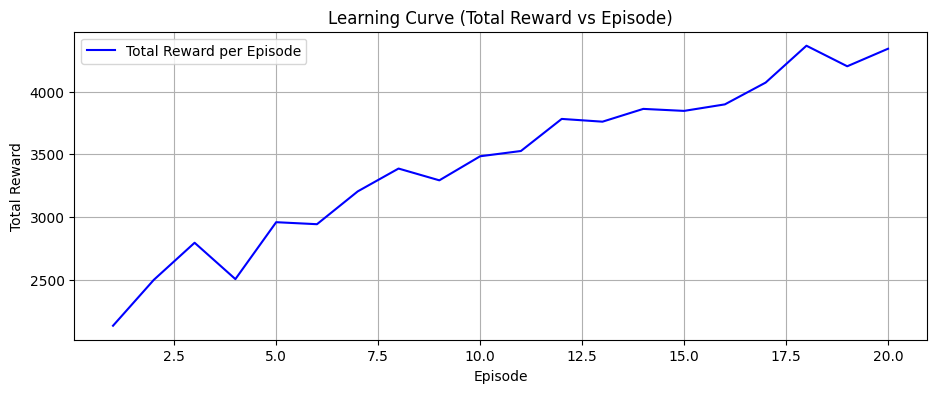

In [79]:
import matplotlib.pyplot as plt

# Define EPISODES (number of training episodes)
EPISODES = 20

# Initialize lists to track rewards for each episode
episode_rewards = []

# Training Loop with Reward Tracking
for episode in range(EPISODES):
    total_reward = 0
    for i in range(len(X)):
        state = X[i]
        action = act(state, EPSILON)
        reward = 1 if action == y[i] else -1

        next_state = X[(i+1) % len(X)]
        done = (i == len(X)-1)

        memory.append((state, action, reward, next_state, done))

        # Sample and train
        if len(memory) >= BATCH_SIZE:
            batch = random.sample(memory, BATCH_SIZE)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.FloatTensor(states).to(device)
            actions = torch.LongTensor(actions).unsqueeze(1).to(device)
            rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
            next_states = torch.FloatTensor(next_states).to(device)
            dones = torch.BoolTensor(dones).unsqueeze(1).to(device)

            q_values = model(states).gather(1, actions)
            next_q_values = model(next_states).max(1)[0].detach().unsqueeze(1)
            target_q_values = rewards + GAMMA * next_q_values * (~dones)

            loss = criterion(q_values, target_q_values)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_reward += reward

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)
    episode_rewards.append(total_reward)  # Append reward for this episode
    print(f"Episode {episode + 1}/{EPISODES}, Reward: {total_reward}, Epsilon: {EPSILON:.3f}")

# Plot Learning Curve
plt.plot(range(1, EPISODES+1), episode_rewards, label='Total Reward per Episode', color='b')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Learning Curve (Total Reward vs Episode)')
plt.grid(True)
plt.legend()
plt.show()


In [80]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()
q_values_list = []
true_labels = []

with torch.no_grad():
    for i in range(len(X_test)):
        state = torch.FloatTensor(X_test.iloc[i].values).to(device)
        q_values = model(state)
        q_values_list.append(q_values[1].item())  # assuming index 1 is "normal"
        true_labels.append(Y_test.iloc[i])

# Compute ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels, q_values_list, pos_label=1)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for DQN-based IDS')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


DQN(
  (fc1): Linear(in_features=41, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=2, bias=True)
)

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

DQL model successfully learned to distinguish between anomalous and normal traffic — showing increasing cumulative rewards and accurate predictions

  Actor-Critic (AC)

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare data
X = train_transformed.drop(['class'], axis=1).values.astype(np.float32)
y = train_transformed['class'].values.astype(np.int64)

STATE_SIZE = X.shape[1]
ACTION_SIZE = 2
EPISODES = 10
GAMMA = 0.99
LR = 0.001

# Actor Network
class Actor(nn.Module):
    def __init__(self, state_size, action_size):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return torch.softmax(self.out(x), dim=-1)

# Critic Network
class Critic(nn.Module):
    def __init__(self, state_size):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)

# Instantiate networks
actor = Actor(STATE_SIZE, ACTION_SIZE).to(device)
critic = Critic(STATE_SIZE).to(device)

actor_optimizer = optim.Adam(actor.parameters(), lr=LR)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR)

# Training loop
for episode in range(EPISODES):
    total_reward = 0
    for i in range(len(X)):
        state = torch.FloatTensor(X[i]).unsqueeze(0).to(device)
        action_probs = actor(state)
        action_dist = torch.distributions.Categorical(action_probs)
        action = action_dist.sample()
        selected_action = action.item()

        reward = 1 if selected_action == y[i] else -1
        total_reward += reward

        next_state = torch.FloatTensor(X[(i + 1) % len(X)]).unsqueeze(0).to(device)
        done = i == len(X) - 1

        # Critic values
        value = critic(state)
        next_value = critic(next_state).detach()

        target = reward + (1 - done) * GAMMA * next_value
        advantage = target - value

        # Critic loss (value error)
        critic_loss = advantage.pow(2).mean()
        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        # Actor loss (policy gradient)
        log_prob = action_dist.log_prob(action)
        actor_loss = -log_prob * advantage.detach()
        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

    print(f"Episode {episode + 1}/{EPISODES}, Total Reward: {total_reward}")


Episode 1/10, Total Reward: 19880


The Actor-Critic model failed to converge and consistently returned negative total rewards despite tuning learning rate, reward function, and training duration.